In [71]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
import pandas as pd
pd.options.mode.copy_on_write = True

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import what_where as ww

# loading the data

In [73]:
figures_dir = ww.utils.ROOT_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

results_dir = ww.utils.ROOT_DIR / "results"

dataset_df = ww.utils.load_dataset_df(ww.utils.ROOT_DIR / "data" / "behavioral_dataset" / "behavioral_dataset.csv")

cfg_fixed = ww.utils.load_config("config_vcs_fixed")
model_df_fixed = ww.utils.load_model_df(cfg_fixed, dataset_df)

cfg_flexible = ww.utils.load_config("config_vcs_flexible")
model_df_flexible = ww.utils.load_model_df(cfg_flexible, dataset_df)

model_df = pd.concat([model_df_fixed, model_df_flexible], ignore_index=True)

model_summary_df = ww.utils.get_model_summary_df(model_df)

energy_breakdown_df = pd.read_csv("energy_use_per_component_vcs_fixed.csv")
energy_breakdown_df

loading model data for journal_fixed
320000 rows in model dataframe before filtering
['ean_global' 'ean_full' 'ean_space' 'baseline' 'ean_features']
320000 rows in model dataframe when returning
loading model data for journal_flexible
4000000 rows in model dataframe before filtering
['baseline' 'ean_full' 'ean_space' 'ean_features' 'ean_global']
4000000 rows in model dataframe when returning

getting model summary dataframe...


,model,instance,energy_cost,cnn_energy_use,rnn_energy_use,gain_energy_use,accuracy
0,baseline,0,-9.0,30569.066010,1124.101115,0.000000,0.4625
1,baseline,1,-9.0,30792.999039,1137.113797,0.000000,0.4275
2,baseline,2,-9.0,30819.157990,1119.429040,0.000000,0.4500
3,baseline,3,-9.0,30727.739044,1104.038658,0.000000,0.4525
4,baseline,4,-9.0,30752.840988,1135.962620,0.000000,0.4425
5,ean_features,0,-7.0,16636.082550,525.117933,50.270758,0.4525
6,ean_features,1,-7.0,16726.439697,500.807356,64.620539,0.4575
7,ean_features,2,-7.0,16694.102158,505.022957,63.098363,0.4325
8,ean_features,3,-7.0,16731.020386,496.575007,66.879833,0.4825
9,ean_features,4,-7.0,16739.072319,509.937475,66.166819,0.4500


In [74]:
plt.rcParams['font.family'] = 'Helvetica'

In [75]:
MODELS, MODEL_NAMES, seaborn_colors = ww.utils.get_seaborn_colors(cfg_flexible)
plot_cfg = cfg_flexible.plotting
seaborn_colors

{'hue': 'model',
 'hue_order': ['baseline',
  'ean_global',
  'ean_features',
  'ean_space',
  'ean_full'],
 'palette': ['#555555', '#5b8efd', '#ffb00d', '#ff5f00', '#dd217d']}

In [76]:
# model_energy_bounds_df = model_summary_df.groupby(["model"]).agg({"log_energy" : ["min", "max"]}).reset_index()
model_energy_bounds_df = model_summary_df.groupby(["experiment", "model"]).agg({
    "negative_energy" : ["min", "max"],
    "energy_savings" : ["min", "max"],
    "log_energy" : ["min", "max"],
    }
    ).reset_index()
model_energy_bounds_df

experiment         model negative_energy            energy_savings  \
                                              min        max            min   
0     journal_fixed      baseline      -10.695490 -10.087645       0.083485   
1     journal_fixed  ean_features      -10.778975  -9.608987       0.000000   
2     journal_fixed      ean_full      -10.580252  -9.619028       0.198723   
3     journal_fixed    ean_global      -10.696778 -10.085201       0.082197   
4     journal_fixed     ean_space      -10.674477 -10.058541       0.104498   
5  journal_flexible      baseline      -10.214420 -10.207257       0.564555   
6  journal_flexible  ean_features      -10.344180  -9.757443       0.434795   
7  journal_flexible      ean_full      -10.229080  -9.731475       0.549895   
8  journal_flexible    ean_global      -10.449421 -10.146720       0.329555   
9  journal_flexible     ean_space      -10.422741 -10.160260       0.356234   

            log_energy             
        max        min        max  
0  0.691330  10.087645  10.695490  
1  1.169989   9.608987  10.778975  
2  1.159947   9.619028  10.580252  
3  0.693774  10.085201  10.696778  
4  0.720435  10.058541  10.674477  
5  0.571718  10.207257  10.214420  
6  1.021532   9.757443  10.344180  
7  1.047500   9.731475  10.229080  
8  0.632255  10.146720  10.449421  
9  0.618715  10.160260  10.422741

In [77]:


# for accuracy
def set_ylim_and_ticks(ax, ylim, step=0.05):
    ax.set_yticks(np.arange(*ylim, step))
    ax.set_ylim((ylim[0], ylim[1]-step))


def plot_accuracy_fixed_accuracy_min_energy_cost(axs):
    sel = model_summary_df["experiment"] == "journal_fixed"
    df = model_summary_df[sel]
    df = df[df["energy_cost"] == df["energy_cost"].min()]

    for i, task in enumerate(["what", "where"]):
        # plot the performance for min energy cost

        sns.barplot(data=df,
                    x="model",
                    y=f"{task}_correct_last",
                    order=plot_cfg
                    **seaborn_colors,
                    ax=axs[i],
                    legend=False,
        )

        # rotate the x-axis labels
        if i == 0: # what task
            axs[i].set_xticks([])
            set_ylim_and_ticks(axs[i], (0.2, 0.9), step=0.1)
        else: # where task
            axs[i].set_xticks(range(len(MODELS)))
            xticklabels = MODEL_NAMES
            xticklabels[-1] = "features\n& space"
            axs[i].set_xticklabels(xticklabels, rotation=70, horizontalalignment='center', fontweight='bold')
            set_ylim_and_ticks(axs[i], (0.2, 1.0), step=0.1)

        axs[i].set_xlabel("")
        axs[i].set_ylabel("")


what ['baseline', 'ean_global', 'ean_features', 'ean_space', 'ean_full']
Plotting model baseline for task what in experiment journal_fixed
Plotting model ean_global for task what in experiment journal_fixed
Plotting model ean_features for task what in experiment journal_fixed
Plotting model ean_space for task what in experiment journal_fixed
Plotting model ean_full for task what in experiment journal_fixed
what ['ean_global', 'ean_features', 'ean_space', 'ean_full', 'baseline']
Plotting model ean_global for task what in experiment journal_flexible
Plotting model ean_features for task what in experiment journal_flexible
Plotting model ean_space for task what in experiment journal_flexible
Plotting model ean_full for task what in experiment journal_flexible
Plotting model baseline for task what in experiment journal_flexible
where ['baseline', 'ean_global', 'ean_features', 'ean_space', 'ean_full']
Plotting model baseline for task where in experiment journal_fixed
Plotting model ean_globa

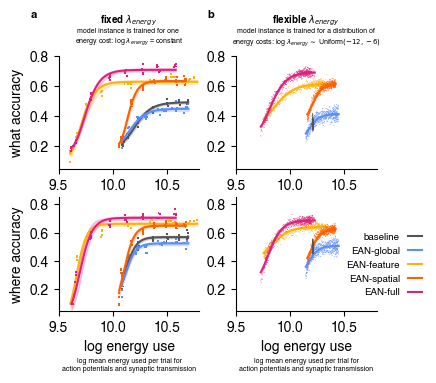

In [ ]:

from matplotlib.gridspec import GridSpec

# Create figure with custom GridSpec for unequal column widths
fig = plt.figure(figsize=(4.5, 3.8))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 0.2], 
              wspace=0.35, hspace=0.25, left=0.15, bottom=0.18, right=1.0, top=0.85)

# Create only the 2x2 plot axes (not using the third column for plots)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(2)])

n_bootstrap = 1000


for i, task in enumerate(["what", "where"]):
    for j, experiment in enumerate(["journal_fixed", "journal_flexible"]):

        ax = axs[i,j]

        if i == 0:
            if experiment == "journal_fixed":
                title = rf'fixed $\lambda_{{energy}}$'
            else:
                title = rf'flexible $\lambda_{{energy}}$'

            ax.text(0.5, 1.25, title, transform=ax.transAxes, fontsize=7, fontweight='bold', ha='center', va='bottom')
            if experiment == "journal_fixed":
                subtitle = f'model instance is trained for one \nenergy cost: log $\\lambda_{{energy}}$ = constant'
            else:
                subtitle = f'model instance is trained for a distribution of\nenergy costs: log $\\lambda_{{energy}} \\sim $ Uniform$(-12, -6)$'
            ax.text(0.5, 1.25, subtitle, transform=ax.transAxes, fontsize=5, fontweight='normal', ha='center', va='top')

        if j == 0:
            ax.set_ylabel(f"{task} accuracy", fontweight='normal')


        if i == 1:
            ax.set_xlabel("log energy use", fontweight='normal')  # Increased labelpad to make room

            # Subtitle/explanation
            ax.text(0.5, -0.42, r"log mean energy used per trial for",
                    fontsize=5, fontweight='regular',
                            transform=ax.transAxes,  # This is important for relative positioning
                            va='top',
                            ha='center')
            ax.text(0.5, -0.49, r"action potentials and synaptic transmission",
                    fontsize=5, fontweight='regular',
                            transform=ax.transAxes,  # This is important for relative positioning
                            va='top',
                            ha='center')


        # plot the performance for energy weight = 0
        sel = model_summary_df["experiment"] == experiment

        n_points = 10000

        if experiment == "journal_fixed":
            models = MODELS
        else:
            models = MODELS[1:] + [MODELS[0]] # baseline on top to be more visible for the flexible experiment

        print(task, models)

        for (k, model) in enumerate(models):
            print(f"Plotting model {model} for task {task} in experiment {experiment}")
            model_sel = sel & (model_summary_df["model"] == model)
            model_data = model_summary_df[model_sel]

            X = model_data["log_energy"].values
            y = model_data[f"{task}_correct_last"].values
            
            energy_bounds_sel_experiment = model_energy_bounds_df["experiment"] == experiment
            energy_bounds_sel = energy_bounds_sel_experiment & (model_energy_bounds_df["model"] == model)

            X_pred = np.linspace(X.min(), X.max(), n_points)[:, np.newaxis]

            plot_function = cfg_flexible.plotting.model_results.plot_function
            bootstrap_model_results_path = results_dir / "bootstrap_model_results" / f"bootstrap_model_results_{model}_{task}_{experiment}_{plot_function}.npz"
            bootstrap_model_results_path.parent.mkdir(parents=True, exist_ok=True)

            if bootstrap_model_results_path.exists() and not cfg_flexible.plotting.model_results.redo_bootstraps:
                with np.load(bootstrap_model_results_path) as data:
                    y_pred = data["y_pred"]
                    y_lower = data["y_lower"]
                    y_upper = data["y_upper"]
            else:
                y_pred, y_lower, y_upper, _ = ww.utils.fit_richards_with_ci(X, y, X_pred, n_bootstrap=n_bootstrap)
                np.savez(bootstrap_model_results_path, y_pred=y_pred, y_lower=y_lower, y_upper=y_upper)

            ax.scatter(model_data["log_energy"],
                        model_data[f"{task}_correct_last"],
                        color=dict(plot_cfg.model_colors)[model],
                        s=2 if experiment == "journal_fixed" else 0.4,
                        edgecolor='none',
                        marker='s' if experiment == "journal_fixed" else 'o', zorder=k)


            ax.plot(X_pred, y_pred, color=dict(plot_cfg.model_colors)[model], label=model, linewidth=1.5) # zorder=k * 100)
            ax.fill_between(X_pred.flatten(), y_lower.flatten(), y_upper.flatten(),
                            color=dict(plot_cfg.model_colors)[model], alpha=0.2) #, zorder=k * 10)

            ax.set_xlim(9.5, 10.8)


for i in range(2):
    for j in range(2):
        ax = axs[i,j]
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if i == 0: # what task
            ax.set_ylim((0.05, 0.8))
        else:
            ax.set_ylim((0.05, 0.85))
        
        # Format y-axis to show one decimal place
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}'.format(y)))

# only one decimal point in xaxis
axs[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
axs[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))

for (j, letter) in enumerate(["a", "b"]):
    axs[0, j].text(-0.2, 1.32, letter, transform=axs[0, j].transAxes, fontsize=8, fontweight='bold', va='bottom')

# Create custom legend handles and labels for bold lines only
legend_handles = [plt.Line2D([0], [0], color=dict(plot_cfg.model_colors)[model], lw=1.5) for model in MODELS]
legend_labels = MODEL_NAMES

# Add the custom legend to the figure in the third column space
fig.legend(legend_handles, legend_labels, loc='center left',
        bbox_to_anchor=(0.77, 0.3),
        prop={
            'weight': 'normal',
            'size' : 7.0,
        },
        markerfirst=False,
        handlelength=1.5,
        frameon=False)

# fig.savefig(figures_dir / f"model_results.png", dpi=500)

where ['baseline', 'ean_global', 'ean_features', 'ean_space', 'ean_full']
Plotting model baseline for task where in experiment journal_fixed
Plotting model ean_global for task where in experiment journal_fixed
Plotting model ean_features for task where in experiment journal_fixed
Plotting model ean_space for task where in experiment journal_fixed
Plotting model ean_full for task where in experiment journal_fixed
where ['ean_global', 'ean_features', 'ean_space', 'ean_full', 'baseline']
Plotting model ean_global for task where in experiment journal_flexible
Plotting model ean_features for task where in experiment journal_flexible
Plotting model ean_space for task where in experiment journal_flexible
Plotting model ean_full for task where in experiment journal_flexible
Plotting model baseline for task where in experiment journal_flexible


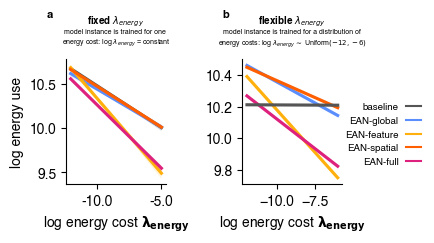

In [79]:

# Create figure with custom GridSpec for unequal column widths
fig = plt.figure(figsize=(4.5, 2.5))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.3],  wspace=1.0, hspace=0.1, left=0.15, bottom=0.25, right=1.0, top=0.75)

# Create only the 2x2 plot axes (not using the third column for plots)
axs = np.array([fig.add_subplot(gs[j]) for j in range(2)])

n_bootstrap = 1000


for j, experiment in enumerate(["journal_fixed", "journal_flexible"]):

    ax = axs[j]

    if experiment == "journal_fixed":
        title = rf'fixed $\lambda_{{energy}}$'
    else:
        title = rf'flexible $\lambda_{{energy}}$'

    ax.text(0.5, 1.25, title, transform=ax.transAxes, fontsize=7, fontweight='bold', ha='center', va='bottom')
    if experiment == "journal_fixed":
        subtitle = f'model instance is trained for one \nenergy cost: log $\\lambda_{{energy}}$ = constant'
    else:
        subtitle = f'model instance is trained for a distribution of\nenergy costs: log $\\lambda_{{energy}} \\sim $ Uniform$(-12, -6)$'
    ax.text(0.5, 1.25, subtitle, transform=ax.transAxes, fontsize=5, fontweight='normal', ha='center', va='top')



    sel = model_summary_df["experiment"] == experiment

    n_points = 10000

    if experiment == "journal_fixed":
        models = MODELS
    else:
        models = MODELS[1:] + [MODELS[0]] # baseline on top to be more visible for the flexible experiment

    print(task, models)

    for (k, model) in enumerate(models):
        print(f"Plotting model {model} for task {task} in experiment {experiment}")
        model_sel = sel & (model_summary_df["model"] == model)
        model_data = model_summary_df[model_sel]


        sns.regplot(model_data,
                     x="energy_cost",
                     y="log_energy",
                    #  **seaborn_colors,
                       color=dict(plot_cfg.model_colors)[model], 
                          scatter=False,
                     ax=ax)
        # ax.legend_.remove()

    ax.set_xlabel(r"log energy cost $\mathbf{\lambda_{energy}}$", fontweight="normal")
    if j == 0:
        ax.set_ylabel("log energy use", fontweight='normal')
    else:
        ax.set_ylabel("")

     
for j in range(2):
    ax = axs[j]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Format y-axis to show one decimal place
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}'.format(y)))

# only one decimal point in xaxis
axs[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
axs[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))

for (j, letter) in enumerate(["a", "b"]):
    axs[j].text(-0.2, 1.32, letter, transform=axs[j].transAxes, fontsize=8, fontweight='bold', va='bottom')

# Create custom legend handles and labels for bold lines only
legend_handles = [plt.Line2D([0], [0], color=dict(plot_cfg.model_colors)[model], lw=1.5) for model in MODELS]
legend_labels = MODEL_NAMES

# Add the custom legend to the figure in the third column space
fig.legend(legend_handles, legend_labels, loc='center left',
        bbox_to_anchor=(0.75, 0.45),
        prop={
            'weight': 'normal',
            'size' : 7.0,
        },
        markerfirst=False,
        handlelength=1.5,
        frameon=False)

# fig.savefig(figures_dir / f"model_results_energy_cost_use.png", dpi=500)

where ['baseline', 'ean_global', 'ean_features', 'ean_space', 'ean_full']
Plotting model baseline for task where in experiment journal_fixed
Plotting model ean_global for task where in experiment journal_fixed
Plotting model ean_features for task where in experiment journal_fixed
Plotting model ean_space for task where in experiment journal_fixed
Plotting model ean_full for task where in experiment journal_fixed
where ['ean_global', 'ean_features', 'ean_space', 'ean_full', 'baseline']
Plotting model ean_global for task where in experiment journal_flexible
Plotting model ean_features for task where in experiment journal_flexible
Plotting model ean_space for task where in experiment journal_flexible
Plotting model ean_full for task where in experiment journal_flexible
Plotting model baseline for task where in experiment journal_flexible


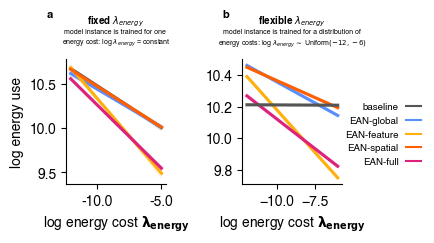

In [80]:
# Create figure with custom GridSpec for unequal column widths
fig = plt.figure(figsize=(4.5, 2.5))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.3],  wspace=1.0, hspace=0.1, left=0.15, bottom=0.25, right=1.0, top=0.75)

# Create only the 2x2 plot axes (not using the third column for plots)
axs = np.array([fig.add_subplot(gs[j]) for j in range(2)])

n_bootstrap = 1000


for j, experiment in enumerate(["journal_fixed", "journal_flexible"]):

    ax = axs[j]

    if experiment == "journal_fixed":
        title = rf'fixed $\lambda_{{energy}}$'
    else:
        title = rf'flexible $\lambda_{{energy}}$'

    ax.text(0.5, 1.25, title, transform=ax.transAxes, fontsize=7, fontweight='bold', ha='center', va='bottom')
    if experiment == "journal_fixed":
        subtitle = f'model instance is trained for one \nenergy cost: log $\\lambda_{{energy}}$ = constant'
    else:
        subtitle = f'model instance is trained for a distribution of\nenergy costs: log $\\lambda_{{energy}} \\sim $ Uniform$(-12, -6)$'
    ax.text(0.5, 1.25, subtitle, transform=ax.transAxes, fontsize=5, fontweight='normal', ha='center', va='top')



    sel = model_summary_df["experiment"] == experiment

    n_points = 10000

    if experiment == "journal_fixed":
        models = MODELS
    else:
        models = MODELS[1:] + [MODELS[0]] # baseline on top to be more visible for the flexible experiment

    print(task, models)

    for (k, model) in enumerate(models):
        print(f"Plotting model {model} for task {task} in experiment {experiment}")
        model_sel = sel & (model_summary_df["model"] == model)
        model_data = model_summary_df[model_sel]


        sns.regplot(model_data,
                     x="energy_cost",
                     y="log_energy",
                    #  **seaborn_colors,
                       color=dict(plot_cfg.model_colors)[model], 
                          scatter=False,
                     ax=ax)
        # ax.legend_.remove()

    ax.set_xlabel(r"log energy cost $\mathbf{\lambda_{energy}}$", fontweight="normal")
    if j == 0:
        ax.set_ylabel("log energy use", fontweight='normal')
    else:
        ax.set_ylabel("")

     
for j in range(2):
    ax = axs[j]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Format y-axis to show one decimal place
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}'.format(y)))

# only one decimal point in xaxis
axs[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
axs[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))

for (j, letter) in enumerate(["a", "b"]):
    axs[j].text(-0.2, 1.32, letter, transform=axs[j].transAxes, fontsize=8, fontweight='bold', va='bottom')

# Create custom legend handles and labels for bold lines only
legend_handles = [plt.Line2D([0], [0], color=dict(plot_cfg.model_colors)[model], lw=1.5) for model in MODELS]
legend_labels = MODEL_NAMES

# Add the custom legend to the figure in the third column space
fig.legend(legend_handles, legend_labels, loc='center left',
        bbox_to_anchor=(0.75, 0.45),
        prop={
            'weight': 'normal',
            'size' : 7.0,
        },
        markerfirst=False,
        handlelength=1.5,
        frameon=False)

# fig.savefig(figures_dir / f"model_results.png", dpi=500)

Text(0, 0.5, 'energy use savings (percent)')

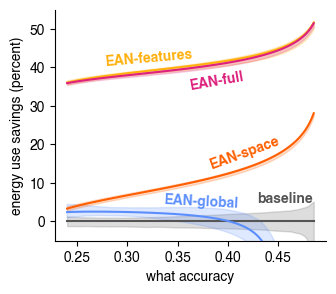

In [81]:
from scipy.interpolate import interp1d

# MODELS_energy_savings = MODELS

experiment = "journal_fixed"
task = "what"
plot_function = cfg_flexible.plotting.model_results.plot_function

fig, ax = plt.subplots(figsize=(3.5, 3.0))

global_min_acc = 0.24
global_max_acc = 0.485

energy_savings_use = {
}

for model in MODELS:
    # loading the bootstrap results for log energy vs accuracy
    bootstrap_model_results_path = results_dir / "bootstrap_model_results" / f"bootstrap_model_results_{model}_{task}_{experiment}_{plot_function}.npz"
    with np.load(bootstrap_model_results_path) as data:
        y_pred = data["y_pred"].flatten()
        y_lower = data["y_lower"].flatten()
        y_upper = data["y_upper"].flatten()

    model_sel = (model_summary_df["experiment"] == experiment) & (model_summary_df["model"] == model)
    model_data = model_summary_df[model_sel]
    X = model_data["log_energy"].values
    # y = model_data[f"{task}_correct_last"].values
    X_pred = np.linspace(X.min(), X.max(), n_points)

    # Invert: given a target accuracy, find the energy
    inv_mean = interp1d(y_pred, X_pred, bounds_error=False, fill_value="extrapolate")
    inv_lower = interp1d(y_upper, X_pred, bounds_error=False, fill_value="extrapolate")  # note: upper y -> lower x
    inv_upper = interp1d(y_lower, X_pred, bounds_error=False, fill_value="extrapolate")  # note: lower y -> upper x

    # Query at desired accuracy levels
    target_accuracies = np.linspace(global_min_acc, global_max_acc, 100)
    energy_mean = np.exp(inv_mean(target_accuracies))
    energy_lower = np.exp(inv_lower(target_accuracies))
    energy_upper = np.exp(inv_upper(target_accuracies))

    energy_savings_use[model] = {
        "accuracy": target_accuracies,
        "energy_mean": energy_mean,
        "energy_lower": energy_lower,
        "energy_upper": energy_upper
    }

energy_savings = {}

for model in MODELS:
    energy_savings[model] = {
        "accuracy": energy_savings_use[model]["accuracy"],
        "energy_savings_mean":  1 - (energy_savings_use[model]["energy_mean"] / energy_savings_use["baseline"]["energy_mean"]),
        "energy_savings_lower": 1 - (energy_savings_use[model]["energy_upper"] / energy_savings_use["baseline"]["energy_mean"]),  # note: upper energy -> lower savings
        "energy_savings_upper": 1 - (energy_savings_use[model]["energy_lower"] / energy_savings_use["baseline"]["energy_mean"]),  # note: lower energy -> upper savings
    }


for model in MODELS:
    ax.fill_between(energy_savings[model]["accuracy"], 100*energy_savings[model]["energy_savings_lower"], 100*energy_savings[model]["energy_savings_upper"], color=dict(plot_cfg.model_colors)[model], alpha=0.2)

for model in MODELS:
    ax.plot(energy_savings[model]["accuracy"], 100*energy_savings[model]["energy_savings_mean"], color=dict(plot_cfg.model_colors)[model], label=model, linewidth=1.5, zorder=10)

ax.text(0.6, 0.69, "EAN-full", color=dict(plot_cfg.model_colors)['ean_full'], fontsize=10, fontweight='bold', ha='center', va='center', transform=ax.transAxes, rotation=10)
ax.text(0.35, 0.79, "EAN-features", color=dict(plot_cfg.model_colors)['ean_features'], fontsize=10, fontweight='bold', ha='center', va='center', transform=ax.transAxes, rotation=5)
ax.text(0.7, 0.38, "EAN-space", color=dict(plot_cfg.model_colors)['ean_space'], fontsize=10, fontweight='bold', ha='center', va='center', transform=ax.transAxes, rotation=20)
ax.text(0.54, 0.17, "EAN-global", color=dict(plot_cfg.model_colors)['ean_global'], fontsize=10, fontweight='bold', ha='center', va='center', transform=ax.transAxes, rotation=-3)
ax.text(0.85, 0.18, "baseline", color=dict(plot_cfg.model_colors)['baseline'], fontsize=10, fontweight='bold', ha='center', va='center', transform=ax.transAxes)

ax.set_ylim(-5, 55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("what accuracy", fontweight='normal')
ax.set_ylabel("energy use savings (percent)", fontweight='normal')

baseline min energy savings: 0.0 max energy savings: 0.0
ean_global min energy savings: -26018.09912158971 max energy savings: 0.025572853443597388
ean_features min energy savings: 0.3606511787039999 max energy savings: 0.5162043139819102
ean_space min energy savings: 0.033433644913065996 max energy savings: 0.2810163043397681
ean_full min energy savings: 0.3592927945312986 max energy savings: 0.5147171268554958
Model baseline: total_energy=31,856, max=34,580, ratio=0.921, radius=2.208
Model ean_global: total_energy=34,580, max=34,580, ratio=1.000, radius=2.300
Model ean_features: total_energy=17,275, max=34,580, ratio=0.500, radius=1.626
Model ean_space: total_energy=26,192, max=34,580, ratio=0.757, radius=2.002
Model ean_full: total_energy=17,997, max=34,580, ratio=0.520, radius=1.659


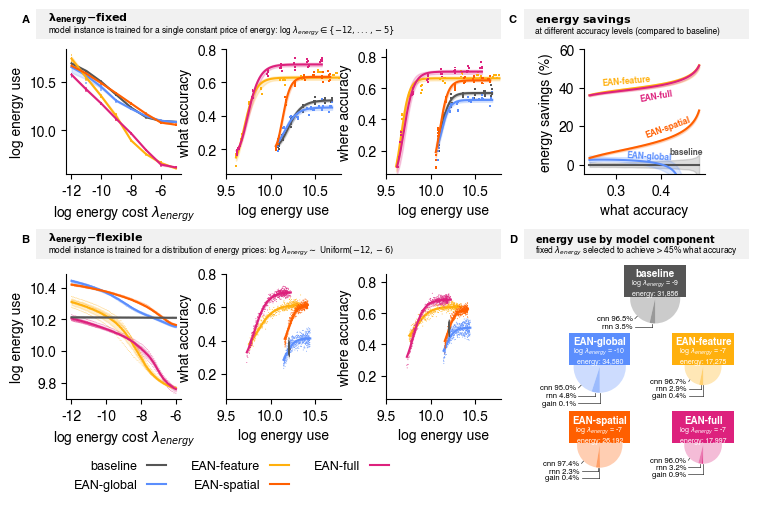

In [84]:
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch

# Create figure with custom GridSpec for unequal column widths (leaving space for legend)
fig = plt.figure(figsize=(7.5, 5.0))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 1.5], height_ratios=[1, 1],
              wspace=0.35, hspace=0.8, left=0.08, bottom=0.2, right=0.95, top=0.90)

# Create 2x3 plot axes for a and b (row 0 and row 2, skipping middle spacer row)
axs = np.array([[fig.add_subplot(gs[0, j]) for j in range(3)],
                [fig.add_subplot(gs[1, j]) for j in range(3)]])

# Create subplot (c) for pie charts - divide into 2x3 grid (2 rows + 2 cols + 1 center)
gs_pies = gs[1:, 3].subgridspec(3, 2, hspace=0.7, wspace=0.5, height_ratios=[1.0, 1.0, 1], width_ratios=[1, 1])

ax_energy_savings = fig.add_subplot(gs[0, 3])

n_bootstrap = 1000
n_points = 10000

# Define global y-positions for the gray boxes and letters (in figure coordinates)
ROW_LABEL_Y = [0.93, 0.49]  # Y positions for rows a and b (shifted up for two-line layout)
LABEL_X = 0.05  # X position for letters a, b, c
BOX_HEIGHT = 0.04  # Taller to fit title + explanation

BOX_WIDTH_AB = 0.6  # Width for boxes a and b
BOX_WIDTH_C = 0.28   # Width for box c

BOX_X_AB = 0.05      # X position for boxes a and b

BOX_X_C = 0.7       # X position for box c

# ========== COMMENTED OUT PARTS A AND B ==========
for i, experiment in enumerate(["journal_fixed", "journal_flexible"]):
    
    # Title for the row
    if experiment == "journal_fixed":
        # title_text = rf'$\mathbf{{fixed}}$ $\mathbf{{\lambda_{{energy}}}}$'
        title_text = rf'$\mathbf{{\lambda_{{energy}}}}\mathbf{{-fixed}}$'
        explanation_text = r'model instance is trained for a single constant price of energy: log $\lambda_{energy} \in \{-12, ..., -5\}$'
    else:
        # title_text = rf'$\mathbf{{flexible}}$ $\mathbf{{\lambda_{{energy}}}}$'
        title_text = rf'$\mathbf{{\lambda_{{energy}}}}\mathbf{{-flexible}}$'
        explanation_text = r'model instance is trained for a distribution of energy prices: log $\lambda_{energy} \sim$ Uniform$(-12, -6)$'
    
    # Add a gray box using figure coordinates
    box = FancyBboxPatch((BOX_X_AB, ROW_LABEL_Y[i]), BOX_WIDTH_AB, BOX_HEIGHT,
                         boxstyle="square,pad=0.01", 
                         transform=fig.transFigure,
                         facecolor='lightgray', alpha=0.3, edgecolor='none',
                         clip_on=False, zorder=-1)
    fig.add_artist(box)
    
    # Add title at the top of the box
    fig.text(BOX_X_AB + 0.005, ROW_LABEL_Y[i] + BOX_HEIGHT * 0.75, title_text, fontsize=8, 
             fontweight='normal', ha='left', va='center')
    
    # Add explanation below the title
    fig.text(BOX_X_AB + 0.005, ROW_LABEL_Y[i] + BOX_HEIGHT * 0.2, explanation_text, fontsize=6, 
             fontweight='normal', ha='left', va='center')
    
    # --- Column 0: Energy cost vs Energy use ---
    ax = axs[i, 0]
    sel = model_summary_df["experiment"] == experiment
    
    if experiment == "journal_fixed":
        models = MODELS
    else:
        models = MODELS[1:] + [MODELS[0]]
    
    for k, model in enumerate(models):
        model_sel = sel & (model_summary_df["model"] == model)
        model_data = model_summary_df[model_sel]
        
        # Scatter plot
        ax.scatter(model_data["energy_cost"],
                   model_data["log_energy"],
                   color=dict(plot_cfg.model_colors)[model],
                   s=2 if experiment == "journal_fixed" else 0.4,
                   edgecolor='none',
                   marker='s' if experiment == "journal_fixed" else 'o',
                   alpha=0.6)
        
        # Regression line
        sns.lineplot(model_data,
                    x="energy_cost",
                    y="log_energy",
                    **seaborn_colors,
                    errorbar=("ci", 95),
                    ax=ax)
        ax.legend_.remove()
    
    ax.set_xlabel(r"log energy cost $\lambda_{energy}$", fontweight="normal")
    ax.set_ylabel("log energy use", fontweight='normal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}'.format(y)))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0f}'.format(x)))
    
    # Set specific x-axis ticks
    if experiment == "journal_fixed":
        ax.set_xticks(range(-12, -4, 2))
    else:
        ax.set_xticks(range(-12, -5, 2))
    
    # --- Columns 1 & 2: Accuracy vs Energy use ---
    for j, task in enumerate(["what", "where"]):
        ax = axs[i, j + 1]
        
        ax.set_ylabel(f"{task} accuracy", fontweight='normal')
        ax.set_xlabel("log energy use", fontweight='normal')
        
        for k, model in enumerate(models):
            model_sel = sel & (model_summary_df["model"] == model)
            model_data = model_summary_df[model_sel]
            
            X = model_data["log_energy"].values
            y = model_data[f"{task}_correct_last"].values
            
            X_pred = np.linspace(X.min(), X.max(), n_points)[:, np.newaxis]
            
            plot_function = cfg_flexible.plotting.model_results.plot_function
            bootstrap_model_results_path = results_dir / "bootstrap_model_results" / f"bootstrap_model_results_{model}_{task}_{experiment}_{plot_function}.npz"
            
            if bootstrap_model_results_path.exists() and not cfg_flexible.plotting.model_results.redo_bootstraps:
                with np.load(bootstrap_model_results_path) as data:
                    y_pred = data["y_pred"]
                    y_lower = data["y_lower"]
                    y_upper = data["y_upper"]
            else:
                if plot_function == "sigmoid":
                    y_pred, y_lower, y_upper, _ = ww.utils.fit_sigmoid_with_ci(X, y, X_pred, n_bootstrap=n_bootstrap)
                elif plot_function == "gompertz":
                    y_pred, y_lower, y_upper, _ = ww.utils.fit_gompertz_with_ci(X, y, X_pred, n_bootstrap=n_bootstrap)
                elif plot_function == "richards":
                    y_pred, y_lower, y_upper, _ = ww.utils.fit_richards_with_ci(X, y, X_pred, n_bootstrap=n_bootstrap)
                else:
                    raise ValueError(f"Unknown plot_function: {plot_function}")
                np.savez(bootstrap_model_results_path, y_pred=y_pred, y_lower=y_lower, y_upper=y_upper)
            
            ax.scatter(model_data["log_energy"],
                      model_data[f"{task}_correct_last"],
                      color=dict(plot_cfg.model_colors)[model],
                      s=2 if experiment == "journal_fixed" else 0.4,
                      edgecolor='none',
                      marker='s' if experiment == "journal_fixed" else 'o', 
                      zorder=k)
            
            ax.plot(X_pred, y_pred, color=dict(plot_cfg.model_colors)[model], 
                   label=model, linewidth=1.5)
            ax.fill_between(X_pred.flatten(), y_lower.flatten(), y_upper.flatten(),
                           color=dict(plot_cfg.model_colors)[model], alpha=0.2)
            
            ax.set_xlim(9.5, 10.8)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        if task == "what":
            ax.set_ylim((0.05, 0.8))
        else:
            ax.set_ylim((0.05, 0.85))
        
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}'.format(y)))
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))

# Add letters a and b using figure coordinates
for i, letter in enumerate(["A", "B"]):
    fig.text(BOX_X_AB - 0.03, ROW_LABEL_Y[i] + BOX_HEIGHT * 0.75, letter, fontsize=8, fontweight='bold', va='center', ha='left')
for i, letter in enumerate(["C", "D"]):
    fig.text(BOX_X_C - 0.03, ROW_LABEL_Y[i] + BOX_HEIGHT * 0.75, letter, fontsize=8, fontweight='bold', va='center', ha='left')


# c : accuracy -> energy_savings plot
from scipy.interpolate import interp1d

# fancy box
title_text = r'$\mathbf{energy\ savings}$'
explanation_text = r'at different accuracy levels (compared to baseline)'

bbox = FancyBboxPatch((BOX_X_C, ROW_LABEL_Y[0]), BOX_WIDTH_C, BOX_HEIGHT,
                      boxstyle="square,pad=0.01",
                      facecolor='lightgray', alpha=0.3, edgecolor='none',
                      clip_on=False, zorder=-1)
fig.add_artist(bbox)

# Add title and explanation text within the box
fig.text(BOX_X_C + 0.005, ROW_LABEL_Y[0] + BOX_HEIGHT * 0.75, title_text, fontsize=8, 
         fontweight='normal', ha='left', va='center')
fig.text(BOX_X_C + 0.005, ROW_LABEL_Y[0] + BOX_HEIGHT * 0.2, explanation_text, fontsize=6, 
         fontweight='normal', ha='left', va='center')


experiment = "journal_fixed"
task = "what"
plot_function = cfg_flexible.plotting.model_results.plot_function


global_min_acc = 0.24
global_max_acc = 0.485

accuracy_energy_use = {
}

for model in MODELS:
    # loading the bootstrap results for log energy vs accuracy
    bootstrap_model_results_path = results_dir / "bootstrap_model_results" / f"bootstrap_model_results_{model}_{task}_{experiment}_{plot_function}.npz"
    with np.load(bootstrap_model_results_path) as data:
        y_pred = data["y_pred"].flatten()
        y_lower = data["y_lower"].flatten()
        y_upper = data["y_upper"].flatten()

    model_sel = (model_summary_df["experiment"] == experiment) & (model_summary_df["model"] == model)
    model_data = model_summary_df[model_sel]
    X = model_data["log_energy"].values
    # y = model_data[f"{task}_correct_last"].values
    X_pred = np.linspace(X.min(), X.max(), n_points)

    # Invert: given a target accuracy, find the energy
    inv_mean = interp1d(y_pred, X_pred, bounds_error=False, fill_value="extrapolate")
    inv_lower = interp1d(y_upper, X_pred, bounds_error=False, fill_value="extrapolate")  # note: upper y -> lower x
    inv_upper = interp1d(y_lower, X_pred, bounds_error=False, fill_value="extrapolate")  # note: lower y -> upper x

    # Query at desired accuracy levels
    target_accuracies = np.linspace(global_min_acc, global_max_acc, 100)
    energy_mean = np.exp(inv_mean(target_accuracies))
    energy_lower = np.exp(inv_lower(target_accuracies))
    energy_upper = np.exp(inv_upper(target_accuracies))

    accuracy_energy_use[model] = {
        "accuracy": target_accuracies,
        "energy_mean": energy_mean,
        "energy_lower": energy_lower,
        "energy_upper": energy_upper
    }

energy_savings = {}

for model in MODELS:
    energy_savings[model] = {
        "accuracy": accuracy_energy_use[model]["accuracy"],
        "energy_savings_mean":  1 - (accuracy_energy_use[model]["energy_mean"] / accuracy_energy_use["baseline"]["energy_mean"]),
        "energy_savings_lower": 1 - (accuracy_energy_use[model]["energy_upper"] / accuracy_energy_use["baseline"]["energy_mean"]),  # note: upper energy -> lower savings
        "energy_savings_upper": 1 - (accuracy_energy_use[model]["energy_lower"] / accuracy_energy_use["baseline"]["energy_mean"]),  # note: lower energy -> upper savings
    }
    print(model, "min energy savings:", energy_savings[model]["energy_savings_mean"].min(), "max energy savings:", energy_savings[model]["energy_savings_mean"].max())

for model in MODELS:
    ax_energy_savings.fill_between(energy_savings[model]["accuracy"], 100*energy_savings[model]["energy_savings_lower"], 100*energy_savings[model]["energy_savings_upper"], color=dict(plot_cfg.model_colors)[model], alpha=0.2)

for model in MODELS:
    ax_energy_savings.plot(energy_savings[model]["accuracy"], 100*energy_savings[model]["energy_savings_mean"], color=dict(plot_cfg.model_colors)[model], label=model, linewidth=1.5, zorder=10)

model_savings_font = 6
ax_energy_savings.text(0.6, 0.63, "EAN-full", color=dict(plot_cfg.model_colors)['ean_full'], fontsize=model_savings_font, fontweight='bold', ha='center', va='center', transform=ax_energy_savings.transAxes, rotation=10, zorder=11)
ax_energy_savings.text(0.35, 0.75, "EAN-feature", color=dict(plot_cfg.model_colors)['ean_features'], fontsize=model_savings_font, fontweight='bold', ha='center', va='center', transform=ax_energy_savings.transAxes, rotation=5, zorder=11)
ax_energy_savings.text(0.7, 0.38, "EAN-spatial", color=dict(plot_cfg.model_colors)['ean_space'], fontsize=model_savings_font, fontweight='bold', ha='center', va='center', transform=ax_energy_savings.transAxes, rotation=20, zorder=11)
ax_energy_savings.text(0.54, 0.15, "EAN-global", color=dict(plot_cfg.model_colors)['ean_global'], fontsize=model_savings_font, fontweight='bold', ha='center', va='center', transform=ax_energy_savings.transAxes, rotation=-3  , zorder=11)
ax_energy_savings.text(0.85, 0.18, "baseline", color=dict(plot_cfg.model_colors)['baseline'], fontsize=model_savings_font, fontweight='bold', ha='center', va='center', transform=ax_energy_savings.transAxes, zorder=11)

ax_energy_savings.set_ylim(-5, 60)
# ax_energy_savings.set_yticks([0, 25, 50])
ax_energy_savings.spines['top'].set_visible(False)
ax_energy_savings.spines['right'].set_visible(False)

ax_energy_savings.set_xlabel("what accuracy", fontweight='normal')
ax_energy_savings.set_ylabel("energy savings (%)", fontweight='normal')

pos = ax_energy_savings.get_position()
ax_energy_savings.set_position([pos.x0 + 0.05, pos.y0, pos.width*0.7, pos.height])  # Shift down slightly to align with other plots



# --- Subplot (d): Energy breakdown by component as PIE CHARTS ---
# Load energy breakdown data
energy_breakdown_df = pd.read_csv("energy_use_per_component_vcs_fixed.csv")
energy_summary = energy_breakdown_df.groupby('model')[['cnn_energy_use', 'rnn_energy_use', 'gain_energy_use']].mean()
energy_summary = energy_summary.reindex(MODELS)

# Calculate total energy for sizing
energy_summary['total'] = energy_summary.sum(axis=1)
max_total = energy_summary['total'].max()

# Calculate percentage of total energy for each component
total_all_energy = energy_summary[['cnn_energy_use', 'rnn_energy_use', 'gain_energy_use']].sum().sum()
energy_summary['cnn_pct'] = 100 * energy_summary['cnn_energy_use'] / total_all_energy
energy_summary['rnn_pct'] = 100 * energy_summary['rnn_energy_use'] / total_all_energy
energy_summary['gain_pct'] = 100 * energy_summary['gain_energy_use'] / total_all_energy
energy_summary['total_pct'] = 100 * energy_summary['total'] / total_all_energy

# Alpha values for each component
COMPONENT_ALPHAS = {'cnn': 0.3, 'rnn': 0.6, 'gain': 1.0}

# Create pie charts - layout: baseline centered on top, 2x2 grid for EAN models below
# Reorder: baseline (idx 0) goes to top center, EAN models (idx 1-4) go to 2x2 grid
pie_order = [0]  # Baseline first (top center)
pie_order += [1, 2, 3, 4]  # EAN models for 2x2 grid
pie_positions_ean = [(1, 0), (1, 1), (2, 0), (2, 1)]  # 2x2 grid positions for EAN models

# Add gray box for energy breakdown section using figure coordinates (single line, so smaller height)
# BOX_HEIGHT_C = 0.02  # Smaller height for single-line box c
box_c = FancyBboxPatch((BOX_X_C, ROW_LABEL_Y[1]), BOX_WIDTH_C, BOX_HEIGHT,
                       boxstyle="square,pad=0.01", 
                       transform=fig.transFigure,
                       facecolor='lightgray', alpha=0.3, edgecolor='none',
                       clip_on=False, zorder=-1)
fig.add_artist(box_c)

# Add title for box c (aligned with top of box)
title_text = r'$\mathbf{energy\ use\ by\ model\ component}$'
fig.text(BOX_X_C + 0.005, ROW_LABEL_Y[1] + BOX_HEIGHT * 0.75, title_text, fontsize=7, fontweight='normal', ha='left', va='center')

# Add explanation for box c below the title
explanation_text_c = r'fixed $\lambda_{energy}$ selected to achieve > 45% what accuracy'
fig.text(BOX_X_C + 0.005, ROW_LABEL_Y[1] + BOX_HEIGHT * 0.2, explanation_text_c, fontsize=6, fontweight='normal', ha='left', va='center')



# Create first_pie_ax just for the pie chart loop (not for adding boxes/text)
first_pie_ax = fig.add_subplot(gs_pies[0, 0])
first_pie_ax.axis('off')

for idx, model in enumerate(MODELS):
    model_color = dict(plot_cfg.model_colors)[model]
    
    # Use same color with different alpha for each component
    cnn_color = mcolors.to_rgba(model_color, alpha=COMPONENT_ALPHAS['cnn'])
    rnn_color = mcolors.to_rgba(model_color, alpha=COMPONENT_ALPHAS['rnn'])
    gain_color = mcolors.to_rgba(model_color, alpha=COMPONENT_ALPHAS['gain'])
    colors = [cnn_color, rnn_color, gain_color]
    
    # Get actual energy values
    cnn_energy = energy_summary.loc[model, 'cnn_energy_use']
    rnn_energy = energy_summary.loc[model, 'rnn_energy_use']
    gain_energy = energy_summary.loc[model, 'gain_energy_use']
    total_energy = energy_summary.loc[model, 'total']

    accuracy = energy_breakdown_df.loc[energy_breakdown_df['model'] == model, 'accuracy'].mean()
    
    # Proportions for the pie chart (within this model)
    sizes = [cnn_energy, rnn_energy, gain_energy]
    
    # Calculate percentages within this model
    cnn_pct = 100 * cnn_energy / total_energy
    rnn_pct = 100 * rnn_energy / total_energy
    gain_pct = 100 * gain_energy / total_energy
    
    # Calculate radius based on total energy (area scales with energy)
    # Area = π * r^2, so r = sqrt(Area/π) = sqrt(energy/π) 
    max_energy = energy_summary['total'].max()
    radius = 2.3 * np.sqrt(total_energy / max_energy)

    print(f"Model {model}: total_energy={total_energy:,.0f}, max={max_energy:,.0f}, ratio={total_energy/max_energy:.3f}, radius={radius:.3f}")
    
    # Position the pie chart
    if idx == 0:
        # Baseline model - top row, centered
        ax_pie = fig.add_subplot(gs_pies[0, 0])
    else:
        # EAN models - 2x2 grid below
        row, col = pie_positions_ean[idx - 1]
        ax_pie = fig.add_subplot(gs_pies[row, col])
    
    # Create labels for pie chart
    component_names = ['cnn', 'rnn', 'gain']
    component_energies = [cnn_energy, rnn_energy, gain_energy]
    component_pcts = [cnn_pct, rnn_pct, gain_pct]
    
    # Create pie chart without labels initially
    wedges, texts = ax_pie.pie(sizes, 
                                colors=colors, 
                                labels=None,  # We'll add labels manually
                                startangle=270,
                                radius=radius)
                                # wedgeprops=dict(edgecolor='white', linewidth=0.0))
    
    # Manually add labels with connecting lines
    for i, (wedge, name, energy, pct) in enumerate(zip(wedges, component_names, component_energies, component_pcts)):
        if energy == 0:
            continue  # Skip labels for zero energy components

        x_label = -radius * 0.9  # Same x position as rnn and gain for alignment

        # Get the angle at the center of the wedge
        ang = (wedge.theta2 + wedge.theta1) / 2.0
        ang_rad = np.radians(ang)
        
        # Position slightly outside the edge of the pie (with gap)
        pie_gap = 0.02  # Small gap between pie and connecting lines
        x_wedge = (radius + pie_gap) * np.cos(ang_rad)
        y_wedge = (radius + pie_gap) * np.sin(ang_rad)
        
        # Small tick from wedge edge
        tick_length = 0.3
        label_gap = 0.2  # Small gap between line end and label
        
        if name == 'cnn':
            # For cnn: position at bottom-left (diagonal tick), above rnn and gain labels
            label_angle = -135  # degrees from horizontal (lower-left direction)
            # Start of tick line at a fixed angle (with gap from pie)
            tick_start_distance = radius + pie_gap
            x_tick_start = tick_start_distance * np.cos(np.radians(label_angle))
            y_tick_start = tick_start_distance * np.sin(np.radians(label_angle))
            
            # End of tick line (label position) - use same x position as rnn/gain for alignment
            label_distance = radius * 1.15
            y_label = label_distance * np.sin(np.radians(label_angle))
            x_line_end = x_label + label_gap  # Line ends slightly to the right of label
            
            # Draw short tick line at diagonal from the side
            ax_pie.plot([x_tick_start, x_line_end], [y_tick_start, y_label], 
                       color='black', linewidth=0.5, alpha=0.8, 
                       zorder=10, clip_on=False)
            ha = 'right'
        else:
            # For rnn and gain: vertical tick + horizontal line (both on left side)
            y_tick = y_wedge - tick_length
            if name == "gain":
                y_tick -= tick_length * 2   # Slightly lower for gain to avoid overlap with rnn label
            ax_pie.plot([x_wedge, x_wedge], [y_wedge, y_tick], 
                       color='black', linewidth=0.5, alpha=0.8, 
                       zorder=10, clip_on=False)
            
            # Horizontal line to label position (both rnn and gain on left)
            x_line_end = x_label + label_gap  # Line ends slightly to the right of label
            ha = 'right'
            
            ax_pie.plot([x_wedge, x_line_end], [y_tick, y_tick], 
                       color='black', linewidth=0.5, alpha=0.8, 
                       zorder=10, clip_on=False)
            y_label = y_tick
        # Add energy and percentage in smaller font
        ax_pie.text(x_label, y_label, f'{name} {pct:.1f}%',
                   ha=ha, va='bottom' if y_label >= 0 else 'center',
                   fontsize=5.5, fontweight='normal', color='black',
                   zorder=11)
    
    # Add model name and details in a single box above the center of the pie
    energy_cost = energy_breakdown_df.loc[energy_breakdown_df['model'] == model, 'energy_cost'].mean()
    model_accuracy = energy_breakdown_df.loc[energy_breakdown_df['model'] == model, 'accuracy'].mean()
    
    # Draw the background box first - fixed size and position for all models
    box_width = 5.3
    box_height = 2.7
    box_y = 0.2  # Fixed position for all models
    label_box = FancyBboxPatch((-box_width/2, box_y), box_width, box_height,
                               boxstyle='square,pad=0.05',
                               facecolor=model_color, edgecolor='none',
                               transform=ax_pie.transData, zorder=5,
                               clip_on=False)  # Prevent clipping at axis boundaries
    ax_pie.add_patch(label_box)
    
    # Add title (model name) - larger font, bold
    ax_pie.text(0.0, box_y + box_height - 0.25, MODEL_NAMES[idx], 
               ha='center', va='top', fontsize=7, fontweight='bold', color="white", zorder=6)
    
    # Add details - smaller font, normal weight
    # details_text = r'log $\lambda_{energy}$ =' + f' {energy_cost:.0f}\nenergy: {total_energy:,.0f}\nwhat acc: {model_accuracy:.2f}'
    details_text = r'log $\lambda_{energy}$ =' + f' {energy_cost:.0f}\nenergy: {total_energy:,.0f}'
    ax_pie.text(0.0, box_y + box_height - 1.1, details_text, 
               ha='center', va='top', fontsize=5, fontweight='normal', color="white", zorder=6)
    
    # push the ax_pie position up/down to adjust vertical position
    # For baseline (idx=0), center it properly between both columns
    if idx == 0:
        pos = ax_pie.get_position()
        # Center between two columns - need larger shift
        ax_pie.set_position([pos.x0 + pos.width * 0.5 + 0.08, pos.y0 - 0.02, pos.width, pos.height])
    elif idx == 1 or idx == 2: # top row of EAN models
        ax_pie.set_position(ax_pie.get_position().translated(0.025, -0.06))
    else: # last row
        ax_pie.set_position(ax_pie.get_position().translated(0.025, -0.12))

    ax_pie.set_aspect('equal', adjustable='box')  # Use set_aspect instead of axis('equal')
    ax_pie.axis('off')

# Create custom legend for models (at the bottom)
legend_handles = [plt.Line2D([0], [0], color=dict(plot_cfg.model_colors)[model], lw=1.5) 
                  for model in MODELS]
legend_labels = MODEL_NAMES
fig.legend(legend_handles, legend_labels, loc='upper center', ncol=len(MODELS), frameon=False,
          handlelength=1.5,
        #   nrows=2,
          ncols=3,
          markerfirst=False,
          prop={'weight': 'normal', 'size': 9.0},
          bbox_to_anchor=(0.3, 0.1))

fig.savefig(figures_dir / f"fig4_model_results.png", dpi=800)
fig.savefig(figures_dir / f"fig4_model_results.pdf", dpi=800)